In [2]:
import torch
torch.cuda.is_available()

True

In [3]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from torch.autograd import Variable
from sklearn.preprocessing import MinMaxScaler

In [4]:
import yfinance as yf

ticker = "GOOGL"
data = yf.download(ticker, start="2015-01-01", end="2025-12-31")

# On supprime le niveau supérieur (le nom du ticker)
data.columns = data.columns.droplevel(1) 

# 1. Supprimer le nom du groupe de colonnes "Price"
data.columns.name = None

# 2. Transformer la Date de "Index" à "Colonne normale"
data = data.reset_index()

print(data.head())

[*********************100%***********************]  1 of 1 completed

        Date      Close       High        Low       Open    Volume
0 2015-01-02  26.278948  26.589104  26.196072  26.430303  26480000
1 2015-01-05  25.778229  26.201531  25.693371  26.159846  41182000
2 2015-01-06  25.142036  25.865072  25.087945  25.829839  54456000
3 2015-01-07  25.068094  25.382717  24.993658  25.355920  46918000
4 2015-01-08  25.155432  25.184710  24.565388  24.887456  73054000


In [5]:
data.drop(['High', 'Low', 'Open', 'Volume'],axis=1,inplace=True)

In [6]:
data.columns

Index(['Date', 'Close'], dtype='object')

In [7]:
data

,Date,Close
0,2015-01-02,26.278948
1,2015-01-05,25.778229
2,2015-01-06,25.142036
3,2015-01-07,25.068094
4,2015-01-08,25.155432
...,...,...
2760,2025-12-23,314.350006
2761,2025-12-24,314.089996
2762,2025-12-26,313.510010
2763,2025-12-29,313.559998


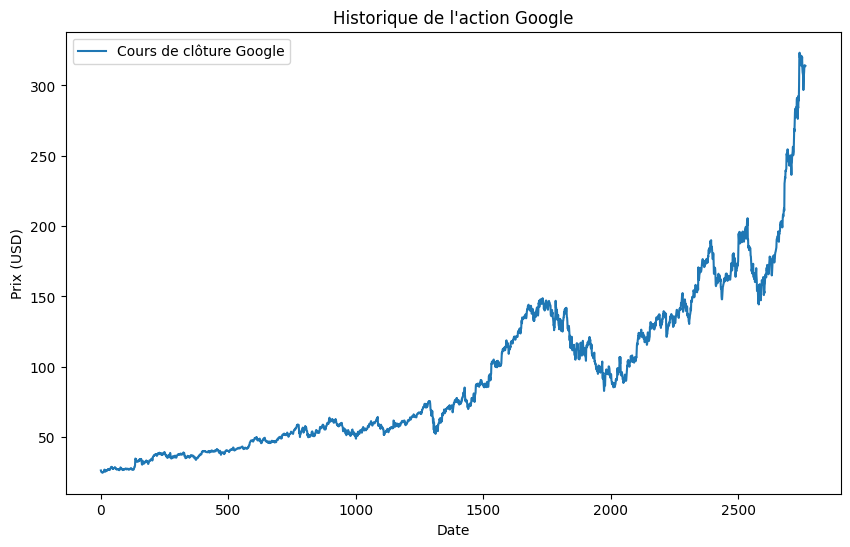

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(data['Close'], label='Cours de clôture Google')
plt.title('Historique de l\'action Google')
plt.xlabel('Date')
plt.ylabel('Prix (USD)')
plt.legend()
plt.show()

In [9]:
df=data[['Close']]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2765 entries, 0 to 2764
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2765 non-null   float64
dtypes: float64(1)
memory usage: 21.7 KB


In [10]:
df=df.fillna(method='ffill')
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(-1, 1))
df['Close'] = scaler.fit_transform(df['Close'].values.reshape(-1,1))

C:\Users\legion\AppData\Local\Temp\ipykernel_22700\3402719577.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df=df.fillna(method='ffill')


In [11]:
type(df.Close)

pandas.core.series.Series

In [12]:
import torch
from torch.autograd import Variable
import numpy as np

def sliding_windows(data, seq_length):
    x = []
    y = []

    for i in range(len(data) - seq_length):
        # On prend une séquence de 'seq_length' jours
        _x = data[i:(i + seq_length)]
        # On veut prédire le prix du jour immédiatement après la séquence
        _y = data[i + seq_length]
        x.append(_x)
        y.append(_y)

    return np.array(x), np.array(y)

# 1. Préparation des fenêtres
seq_length = 60  # On utilise les 60 derniers jours (environ 3 mois de bourse)
x, y = sliding_windows(df['Close'].values, seq_length)

# 2. Séparation Train / Test (80% / 20%)
train_size = int(len(y) * 0.8)
test_size = len(y) - train_size

# 3. Conversion en Tenseurs PyTorch (Format Float32 impératif)
# .reshape(-1, seq_length, 1) garantit le format [Batch, Sequence, Feature]
trainX = torch.Tensor(x[0:train_size]).reshape(-1, seq_length, 1)
trainY = torch.Tensor(y[0:train_size]).reshape(-1, 1)

testX = torch.Tensor(x[train_size:len(x)]).reshape(-1, seq_length, 1)
testY = torch.Tensor(y[train_size:len(y)]).reshape(-1, 1)

print(f"Forme de trainX : {trainX.shape}") # Doit être (N, 60, 1)
print(f"Forme de trainY : {trainY.shape}") # Doit être (N, 1)

Forme de trainX : torch.Size([2164, 60, 1])
Forme de trainY : torch.Size([2164, 1])


In [13]:
import torch
import torch.nn as nn

class GoogleStockLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(GoogleStockLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # L'unité LSTM
        # batch_first=True signifie que l'entrée est (batch, seq, feature)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        
        # Couche de sortie : transforme la sortie du LSTM en un seul prix
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Initialisation automatique des états cachés (h0) et de cellule (c0) à zéro
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Passage dans le LSTM
        # out contient les sorties de chaque pas de temps (seq_length)
        out, (hn, cn) = self.lstm(x, (h0, c0))
        
        # On ne veut que le dernier jour de la séquence pour prédire le lendemain
        # out[:, -1, :] récupère le dernier état caché de la séquence
        out = self.fc(out[:, -1, :])
        
        return out

## TRAINING

In [14]:
# 1. Configuration des Hyperparamètres
num_epochs = 2000
learning_rate = 0.001 # Un taux un peu plus bas (0.001) est souvent plus stable pour Adam

input_size = 1        # Une seule feature : le prix Close
hidden_size = 64      # On augmente à 64 pour capturer des motifs complexes
num_layers = 1        # Une couche pour commencer (tu pourras tester 2 plus tard)
num_classes = 1       # On prédit une seule valeur

hist = np.zeros(num_epochs)

# 2. Initialisation du modèle, de la perte et de l'optimiseur
lstm = GoogleStockLSTM(input_size, hidden_size, num_layers, num_classes)

# MSE (Mean Squared Error) est parfait pour la régression de prix
criterion = torch.nn.MSELoss()    

# Adam est généralement plus performant que le SGD pour les séries temporelles
optimizer = torch.optim.Adam(lstm.parameters(), lr=learning_rate)

# 3. Boucle d'entraînement
for epoch in range(num_epochs):
    lstm.train() # Mode entraînement
    
    # Forward pass : prédiction
    outputs = lstm(trainX)
    
    # Remise à zéro des gradients
    optimizer.zero_grad()
    
    # Calcul de la différence entre prédiction et réalité
    loss = criterion(outputs, trainY)
    
    # Backpropagation : calcul de l'erreur pour chaque poids
    loss.backward()
    
    # Mise à jour des poids du modèle
    optimizer.step()
    
    # Affichage de la progression tous les 100 cycles
    if epoch % 100 == 0:
      print(f"Epoch: {epoch}, MSE: {loss.item():1.5f}")
    hist[epoch] = loss.item()

Epoch: 0, MSE: 0.67304
Epoch: 100, MSE: 0.00644
Epoch: 200, MSE: 0.00081
Epoch: 300, MSE: 0.00042
Epoch: 400, MSE: 0.00038
Epoch: 500, MSE: 0.00037
Epoch: 600, MSE: 0.00036
Epoch: 700, MSE: 0.00035
Epoch: 800, MSE: 0.00034
Epoch: 900, MSE: 0.00033
Epoch: 1000, MSE: 0.00032
Epoch: 1100, MSE: 0.00031
Epoch: 1200, MSE: 0.00030
Epoch: 1300, MSE: 0.00029
Epoch: 1400, MSE: 0.00028
Epoch: 1500, MSE: 0.00027
Epoch: 1600, MSE: 0.00026
Epoch: 1700, MSE: 0.00026
Epoch: 1800, MSE: 0.00025
Epoch: 1900, MSE: 0.00024


## VISUALISATION DES DONNEES

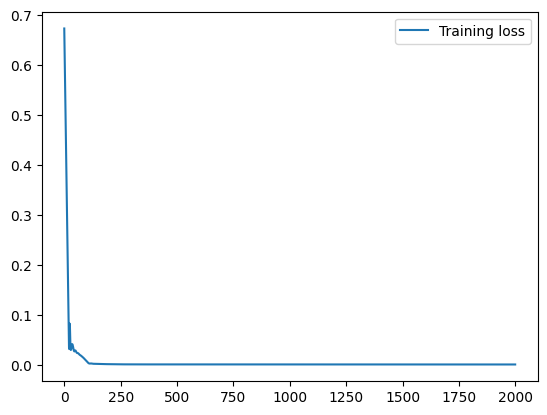

In [15]:
plt.plot(hist, label="Training loss")
plt.legend()
plt.show()

In [16]:
np.shape(outputs)

torch.Size([2164, 1])

### TESTING

In [33]:
from sklearn.metrics import mean_squared_error
from math import sqrt
import math, time

# 1. Passer en mode évaluation (désactive le dropout, etc.)
lstm.eval()
# make predictions
y_test_pred = lstm(testX)

# invert predictions
y_train_pred = scaler.inverse_transform(outputs.detach().numpy())
y_train = scaler.inverse_transform(trainY.detach().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().numpy())
test_predict_rescaled = y_test_pred
y_test = scaler.inverse_transform(testY.detach().numpy())

# calculate root mean squared error
trainScore = math.sqrt(mean_squared_error(y_train[:,0], y_train_pred[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = math.sqrt(mean_squared_error(y_test[:,0], y_test_pred[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

Train Score: 2.30 RMSE
Test Score: 20.77 RMSE


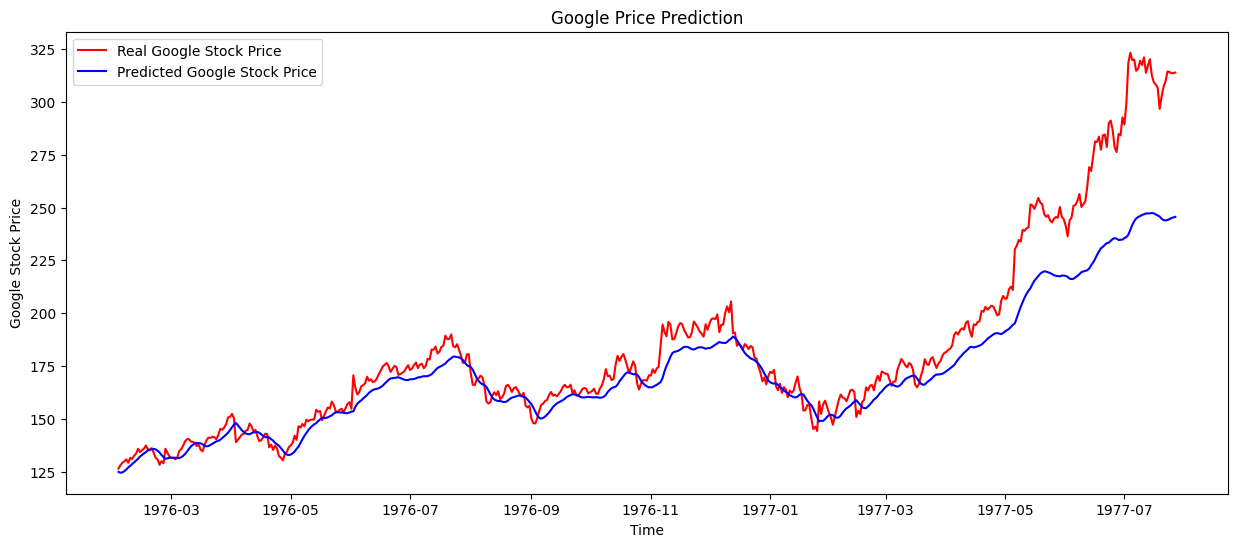

In [18]:
# Visualising the results
import matplotlib.pyplot as plt
figure, axes = plt.subplots(figsize=(15, 6))
axes.xaxis_date()

axes.plot(df[len(df)-len(y_test):].index, y_test, color = 'red', label = 'Real Google Stock Price')
axes.plot(df[len(df)-len(y_test):].index, y_test_pred, color = 'blue', label = 'Predicted Google Stock Price')
#axes.xticks(np.arange(0,394,50))
plt.title('Google Price Prediction')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
plt.legend()
plt.savefig('google_pred.png')
plt.show()

In [19]:
# Save the model state dictionary
torch.save(lstm.state_dict(), 'lstm_model.pth') 
print("Model saved successfully!")

Model saved successfully!


## Prediction

In [20]:
import numpy as np

# Example new data (batch_size, seq_len, input_dim)
new_data = np.random.rand(1,25, 1)  # Adjust seq_len and input_dim as needed
new_data_tensor = torch.tensor(new_data, dtype=torch.float32)
new_data_tensor


tensor([[[0.2287],
         [0.4962],
         [0.7817],
         [0.0471],
         [0.0408],
         [0.9070],
         [0.2245],
         [0.0232],
         [0.8844],
         [0.4263],
         [0.6918],
         [0.8042],
         [0.8910],
         [0.7065],
         [0.7321],
         [0.5922],
         [0.8440],
         [0.0204],
         [0.1460],
         [0.9298],
         [0.8849],
         [0.9971],
         [0.6124],
         [0.2233],
         [0.7057]]])

In [21]:
# Make predictions
with torch.no_grad():  # Disable gradient computation for inference
    predictions = lstm(new_data_tensor)
    n_predictions = scaler.inverse_transform(predictions)

print("Predictions:", n_predictions)


Predictions: [[227.49970724]]


In [22]:
# prédiction sur plusieurs jours, le loopback est defini a 1, on predit après chaque un jour et a chaque prediction sur un jour, 
# on le stocke dans le nouveau dataset pour qu'il serve de predictions pour les prochains jours ainsi de suite

# 1. Préparation de la séquence de départ (les derniers jours connus)
# On prend la dernière fenêtre du dataset de test
last_sequence = testX[-1:].clone() # Shape: (1, seq_length, 1)

future_predictions = []
projection_days = 100 # Nombre de jours à prédire dans le futur

lstm.eval()
with torch.no_grad():
    for _ in range(projection_days):
        # Prédire le jour suivant
        prediction = lstm(last_sequence) # Shape: (1, 1)
        
        # Stocker la prédiction
        future_predictions.append(prediction.item())
        
        # MISE À JOUR DE LA SÉQUENCE :
        # On retire le premier élément et on ajoute la prédiction à la fin
        # prediction.view(1, 1, 1) permet de garder le bon format de tenseur
        new_feature = prediction.view(1, 1, 1)
        last_sequence = torch.cat((last_sequence[:, 1:, :], new_feature), dim=1)

# 2. Inverser la normalisation pour avoir les prix réels
future_predictions = np.array(future_predictions).reshape(-1, 1)
future_predictions_rescaled = scaler.inverse_transform(future_predictions)

In [23]:
# --- ÉTAPE DE DÉFINITION DES VARIABLES INVERSÉES ---

# 1. On récupère les prédictions du modèle sur l'ensemble des données (trainX)
lstm.eval()
with torch.no_grad():
    all_predict = lstm(trainX).cpu().numpy()
    all_actual = trainY.cpu().numpy()


# On transforme les données de [0, 1] vers les prix réels en dollars
all_predict_inv = scaler.inverse_transform(all_predict)
all_actual_inv = scaler.inverse_transform(all_actual)


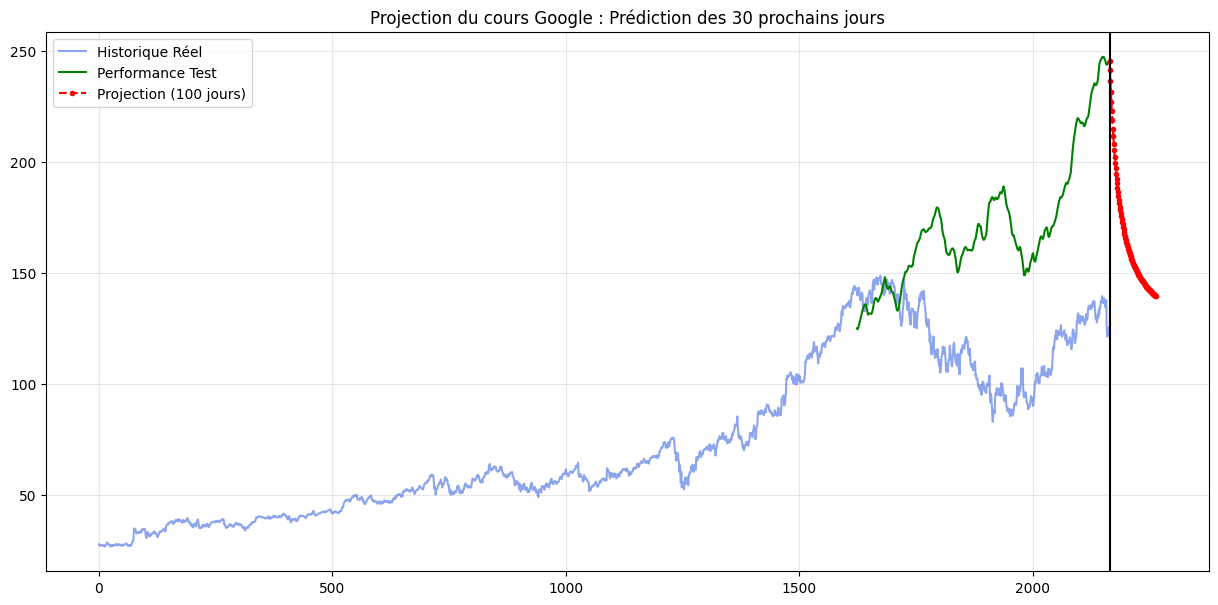

In [34]:
# Création d'un index pour le futur
last_index = len(all_actual_inv)
future_indices = np.arange(last_index, last_index + projection_days)


plt.figure(figsize=(15, 7))

# 1. Données historiques (Prix réels)
plt.plot(all_actual_inv, label='Historique Réel', color='royalblue', alpha=0.6)

# 2. Tes prédictions de test précédentes (en vert)

plt.plot(np.arange(len(all_actual_inv) - len(test_predict_rescaled), len(all_actual_inv)), test_predict_rescaled,
         label='Performance Test', color='green')
# 3. La PROJECTION dans le futur (en pointillés rouges)
plt.plot(future_indices, future_predictions_rescaled, 
         label='Projection (100 jours)', color='red', linestyle='--', marker='o', markersize=3)

plt.axvline(x=last_index, color='black', linestyle='-') # Ligne "Aujourd'hui"
plt.title('Projection du cours Google : Prédiction des 30 prochains jours')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [36]:

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [41]:
# Mettre le modèle en mode évaluation
lstm.eval()

# Créer un exemple d'entrée (dummy input) pour tracer le graphe du modèle
# La taille doit correspondre à (Batch, Seq_Length, Input_Size).
example_input = torch.rand(1, 60, 1)

# "Tracer" le modèle
traced_script_module = torch.jit.trace(lstm, example_input)

# Sauvegarder le modèle complet (Architecture + Poids)
traced_script_module.save("lstm_final.pt")
print("Modèle exporté avec succès sous 'lstm_final.pt'")

Modèle exporté avec succès sous 'lstm_final.pt'
